# 07_pseudotime_compare

In [5]:
%load_ext autoreload
%autoreload 2

In [23]:
%matplotlib inline

In [7]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
from pathlib import Path

In [8]:
combined_fn = "results/07/pseudotime_momac_all.tsv"
combined_df = pd.read_csv(combined_fn, sep="\t", index_col=0, header=[0, 1])

In [9]:
combined_df['dpt_momac_smooth_full']

,pseudotime,DPT_root,DPT_atrem,DPT_igg
cell_id,,,,
M0.22,0.860617,0.860617,0.094707,0.221023
M1.91,0.958245,0.958245,0.079901,0.307176
M2.23,0.486654,0.486654,0.462063,0.246360
M3.06,0.846631,0.846631,0.162309,0.239442
M4.31,0.640452,0.640452,0.343509,0.203320
M5.66,0.216260,0.216260,0.768674,0.534070
M6.85,0.820187,0.820187,0.201968,0.248097
M7.39,0.000000,0.000000,0.921940,0.683857
M8.06,1.004061,1.004061,0.160838,0.369168


In [10]:
gene_set_counts_df = pd.read_csv("results/07/gene_set_sizes.tsv", sep="\t", index_col=0)

In [11]:
gene_set_counts_df

,n_genes_raw,n_genes_in_adata
gene_set,,
momac,17,17
momac_smooth,19,19
momac_hvg,1001,1001
momac_zman_s3,1120,1117
momac_full,50,50
momac_smooth_full,57,57


In [12]:
from scipy.stats import spearmanr

In [13]:
methods = ['scorpius', 'dpt', 'redpath', 'monocle2', 'palantir']
gene_sets = ['_zman_s3', '_hvg', '_full', '_smooth_full']
rename_gene_sets = ['zman_s3', 'hvg', 'full', 'smooth_full']

# zman_s3, hvg, 
# naive (spearman on hvg only using raw cTET), 
# smooth (spearman on hvg only using smoothed cTET), 
# full - spearman on full set using raw cTET, smooth_full (spearman on full set using smoothed cTET)

def get_corr_df(combined_df, put_time_col='cTET'):

    method_gene_set_corr_df = pd.DataFrame(index=pd.MultiIndex.from_product([methods, gene_sets]), columns=["correlation", "pval"])
    method_gene_set_corr_df.index.names = ["method", "gene_set"]
    for method in methods:
        for gene_set in gene_sets:
            col_name = f"{method}_momac{gene_set}"
            spearman_corr, pval = spearmanr(combined_df[('meta', put_time_col)], combined_df[(col_name, 'pseudotime')])
            method_gene_set_corr_df.loc[(method, gene_set), 'correlation'] = spearman_corr
            method_gene_set_corr_df.loc[(method, gene_set), 'pval'] = pval
            
    method_gene_set_corr_df = method_gene_set_corr_df.reset_index()
    method_gene_set_corr_df['gene_set'] = method_gene_set_corr_df['gene_set'].replace('', '_naive')
    method_gene_set_corr_df['gene_set'] = method_gene_set_corr_df['gene_set'].apply(lambda x: x.strip('_'))
    method_gene_set_corr_df['gene_set'] = pd.Categorical(method_gene_set_corr_df['gene_set'], categories=rename_gene_sets, ordered=True)
    return method_gene_set_corr_df

In [14]:
raw_corr_df = get_corr_df(combined_df, put_time_col='cTET')
smooth_corr_df = get_corr_df(combined_df, put_time_col='smooth_cTET')


In [15]:
sns.barplot(data=raw_corr_df, x="method", y="correlation", hue="gene_set", legend=True, palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("raw cTET correlation")
plt.ylim(-1, 1)
plt.show()

In [16]:
sns.barplot(data=smooth_corr_df, x="method", y="correlation", hue="gene_set", legend=True, palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("Smoothed cTET correlation")
plt.ylim(-1, 1)
plt.show()

In [17]:
combined_df[('meta', 'metacell_cell_type')].unique()

array(['Arg1_TAM', 'Acp5_TAM', 'MoMac1', 'MoMac2', 'Monocytes',
       'Gpnmb_TAM'], dtype=object)

In [18]:
cell_type_colors = {
    'Arg1_TAM': 'tab:blue', 'Acp5_TAM': 'tab:purple', 'MoMac1': 'orange', 'MoMac2': 'green', 'Monocytes': 'yellow',
       'Gpnmb_TAM': 'red'
}

In [19]:
myeloid_cell_type_colors = {
    'Arg1_TAM': "mediumorchid", 
    'Acp5_TAM': "slateblue", 
    'MoMac1': "tab:blue", 
    'MoMac2': "tab:red", 
    'Monocytes': "tab:orange", 
    'cDC2': "goldenrod", 
    'MonDC': "gold", 
    'Gpnmb_TAM': "lightblue", 
    'cDC1': "darkkhaki", 
    'MigDC': "tab:brown",
    'transitory': "teal",
    "pDC": "tab:green",
}


In [26]:
def plot_pseudotime_scatter(combined_df, methods, gene_sets, coor_df, ctet_col='cTET'):
    fig, axes = plt.subplots(len(gene_sets), len(methods), figsize=(15, 10), sharex=True)
    for i, method in enumerate(methods):
        for j, gene_set in enumerate(gene_sets):
            col_name = f"{method}_momac{gene_set}"

            last = j == 0 and i == len(methods) - 1
            sns.scatterplot(
                x=combined_df[('meta', ctet_col)], 
                y=combined_df[(col_name, 'pseudotime')], 
                hue=combined_df[('meta', 'metacell_cell_type')],
                palette=cell_type_colors, s=50, edgecolor='black', linewidth=0.5,
                ax=axes[j, i], legend=False if not last else True
            )
            axes[j, i].set_title(f"{method} (r={coor_df.loc[(method, gene_set.strip('_')), 'correlation']:.2f})")
            axes[j, i].set_ylabel(f'{gene_set.strip("_")} (n={gene_set_counts_df.loc[f"momac{gene_set}", "n_genes_in_adata"]})')
            # axes[j, i].set_xlim(0, 1)
            # axes[j, i].set_ylim(0, 1)
            axes[j, i].set_xlabel(f'{ctet_col}')

            if last:
                axes[j, i].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

    plt.tight_layout()
    plt.show()


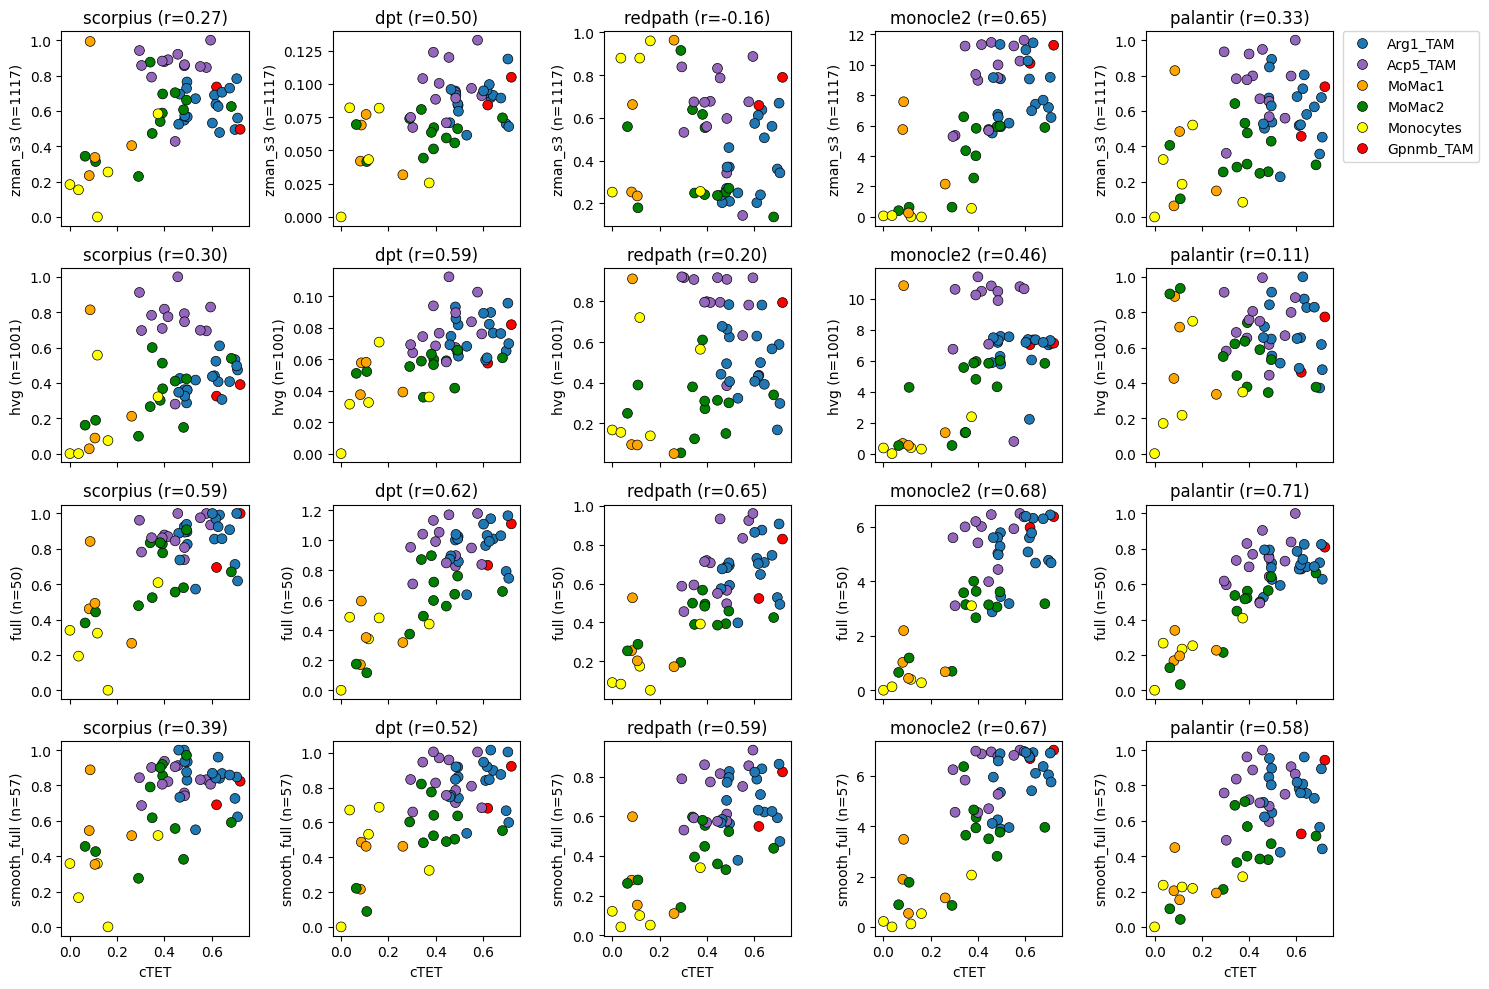

In [27]:
%matplotlib inline
plot_pseudotime_scatter(combined_df, methods, gene_sets, raw_corr_df.set_index(['method', 'gene_set']), ctet_col='cTET')

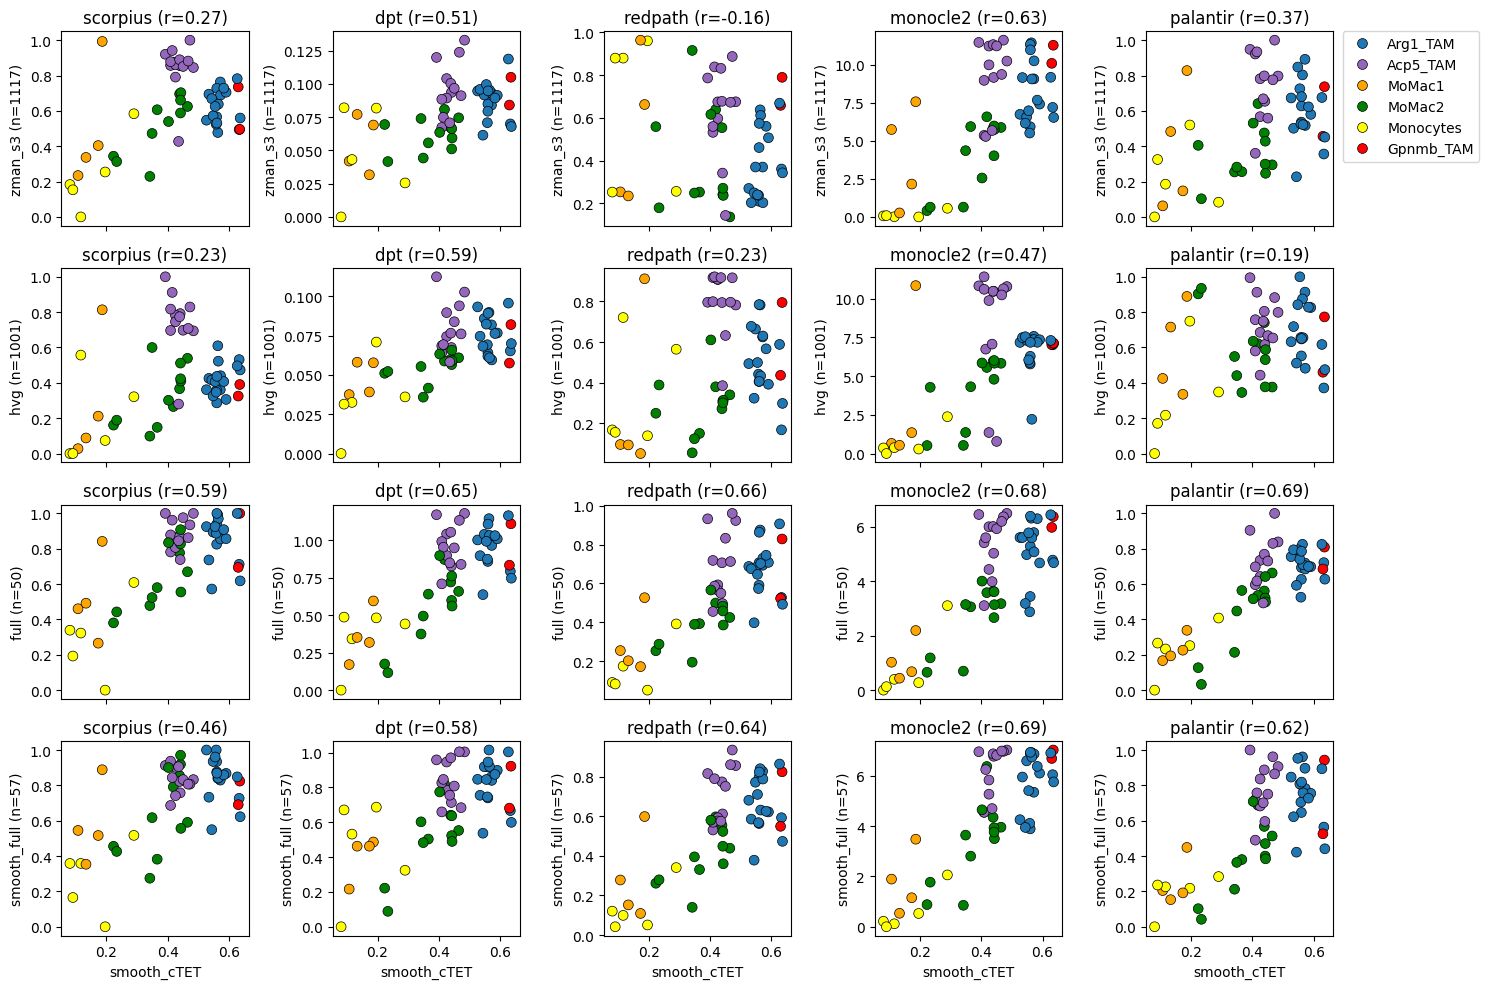

In [28]:
plot_pseudotime_scatter(combined_df, methods, gene_sets, smooth_corr_df.set_index(['method', 'gene_set']), ctet_col='smooth_cTET')

Monocle2 can produce pseudotimes larger than 1. This is because this represents an actual distance in the manifold

Todo: set the root to a monocyte for all of them

In [224]:
combined_df['dpt_momac']

,pseudotime,DPT_root,DPT_atrem,DPT_igg
cell_id,,,,
M0.22,2.058845,2.058845,0.447845,0.290709
M1.91,2.228731,2.228731,0.141605,0.385185
M2.23,1.242187,1.242187,1.154821,0.771400
M3.06,2.105249,2.105249,0.461529,0.329938
M4.31,1.179709,1.179709,1.232497,0.853323
M5.66,0.083505,0.083505,2.347854,2.003814
M6.85,1.651623,1.651623,0.816343,0.432952
M7.39,0.000000,0.000000,2.285033,1.941256
M8.06,2.272677,2.272677,0.153723,0.432393
